## **GRADIENT DESCENT IMPLEMENTATION**

### Linear Regression Gradient Descent

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/dataset

/content/drive/MyDrive/dataset


In [3]:
#Import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.stats as stats

#Pipeline implementation
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import SGDRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random

In [4]:
#Load dataset
df = pd.read_csv('/content/drive/MyDrive/dataset/Housing.csv')

In [5]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
19,8855000,6420,3,2,2,yes,no,no,no,yes,1,yes,semi-furnished
502,2660000,3480,2,1,1,yes,no,no,no,no,1,no,semi-furnished
112,6083000,4300,6,2,2,yes,no,no,no,no,0,no,furnished
514,2485000,3000,3,1,2,no,no,no,no,no,0,no,semi-furnished
279,4270000,6360,2,1,1,yes,no,no,no,no,0,no,furnished


In [6]:
X = df.drop('price',axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
numerical_features = X.select_dtypes(exclude="object").columns
categorical_features = X.select_dtypes(include="object").columns

In [8]:
categorical_features

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
X_train.shape

(436, 12)

In [10]:
#Batch gradient descent
class Batch_Gradient :
  def __init__(self,learning_rate = 0.01,epochs = 100):
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.coef_ = None
    self.intercept_ = None

  def fit(self,X_train,y_train):
    self.intercept_ = 0
    self.coef_ = np.ones(X_train.shape[1])

    for i in range(self.epochs):
      y_hat = np.dot(X_train,self.coef_) + self.intercept_
      slope_intercept = -2 * np.mean(y_train - y_hat)
      self.intercept_ = self.intercept_ - (self.learning_rate * slope_intercept)
      # Ensure X_train is treated as a 2D array for dot product
      slope_coef = -2 * np.dot((y_train - y_hat),X_train) / X_train.shape[0]
      self.coef_ = self.coef_ - (self.learning_rate * slope_coef)
      # print(self.intercept_,self.coef_) # Removed print to avoid verbose output

  def predict(self,X_test):
    return np.dot(X_test,self.coef_) + self.intercept_

In [11]:
class Mini_Batch_Gradient :
  def __init__(self,learning_rate = 0.01,epochs = 100, batch_size = 32):
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.batch_size = batch_size
    self.coef_ = None
    self.intercept_ = None

  def fit(self,X_train,y_train):
    self.coef = np.zeros(X_train.shape[1])
    self.intercept = 0
    batch = int(X_train.shape[0]/self.batch_size)
    for i in range(self.epochs):
      for j in range(batch):
        idx = random.sample(range(X_train.shape[0]),self.batch_size)
        # Corrected indexing using .iloc
        y_hat = np.dot(X_train.iloc[idx],self.coef) + self.intercept

        diff_coef = -2 * np.dot((y_train.iloc[idx] - y_hat),X_train.iloc[idx]) / self.batch_size
        self.coef = self.coef - (self.learning_rate * diff_coef)

        diff_intercept = -2 * np.mean(y_train.iloc[idx] - y_hat)
        self.intercept = self.intercept - (self.learning_rate * diff_intercept)

  def predict(self,X_test):
    return np.dot(X_test,self.coef) + self.intercept

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


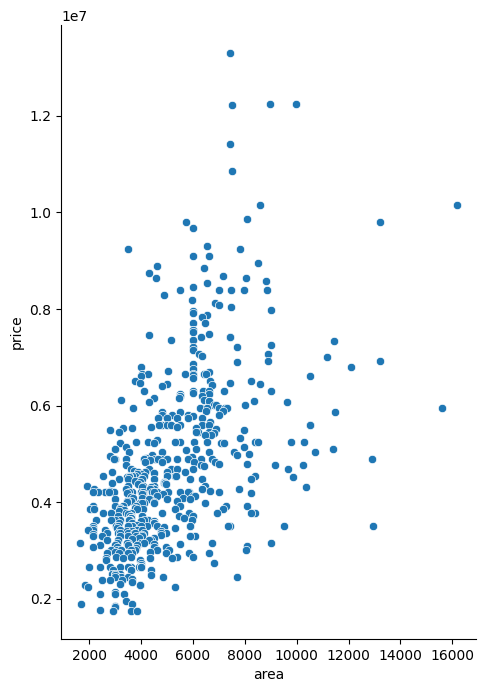

In [12]:
sns.pairplot(df, x_vars='area', y_vars='price',size=7, aspect=0.7, kind='scatter')

In [13]:
tf1 = ColumnTransformer([
    ('imputer 1',SimpleImputer(strategy ='mean'),numerical_features),
    ('imputer 2',SimpleImputer(strategy='most_frequent'),categorical_features)],
    remainder='passthrough', verbose_feature_names_out=False).set_output(transform ='pandas')

tf1

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer 1', SimpleImputer(),
                                 Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')),
                                ('imputer 2',
                                 SimpleImputer(strategy='most_frequent'),
                                 Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [14]:
df[categorical_features[-1]].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [15]:
tf2 = ColumnTransformer(
    [('encoder 1',OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),categorical_features[:-1]),
    ('encoder 2', OrdinalEncoder(categories=[['unfurnished','semi-furnished','furnished']]),[categorical_features[-1]])], # Wrapped in a list
     remainder='passthrough',
    verbose_feature_names_out=False).set_output(transform ='pandas')

tf2

ColumnTransformer(remainder='passthrough',
                  transformers=[('encoder 1',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea'],
      dtype='object')),
                                ('encoder 2',
                                 OrdinalEncoder(categories=[['unfurnished',
                                                             'semi-furnished',
                                                             'furnished']]),
                                 ['furnishingstatus'])],
                  verbose_feature_names_out=False)

In [16]:
tf3 = StandardScaler()
tf3

StandardScaler()

In [17]:
#r2_scores = []
#
## Use np.arange for float steps for learning_rate (x)
#for x in np.arange(0.001, 0.1, 0.002): # Iterate x from 0.01 to 1.0 with step 0.#01
#  # Iterate y (epochs) with a larger step to reduce computation
#  for y in range(100, 1001, 100): # Iterate y from 100 to 1000 with step 100
#    # Corrected instantiation of Mini_Batch_Gradient
#    tf4 = Mini_Batch_Gradient(learning_rate=x, epochs=y, batch_size=int(X_train.#shape[0]/40))
#
#    pipe = Pipeline(
#    [
#     ('tf1',tf1),
#     ('tf2',tf2),
#     ('tf3',tf3),
#     ('tf4',tf4)
#    ])
#
#    pipe.set_output(transform='pandas')
#    pipe.fit(X_train,y_train)
#
#    y_pred  = pipe.predict(X_test)
#
#    r2 = r2_score(y_test, y_pred)
#
#    r2_scores.append((x,y,r2))
#
#    print(f"Learning Rate: {x:.3f}, Epochs: {y}, R-squared: {r2:.4f}")

In [18]:
#r2_scores_df = pd.DataFrame(r2_scores, columns=['Learning Rate', 'Epochs', #'R-squared'])
#r2_scores_df[r2_scores_df['R-squared'] == r2_scores_df['R-squared'].max()]

In [19]:
#tf4 = Batch_Gradient(learning_rate=0.033, epochs = 100)
#tf4 = SGDRegressor(learning_rate='constant', eta0=0.01, max_iter=100)
tf4 = Mini_Batch_Gradient(learning_rate=0.013, epochs = 800 , batch_size = int(X_train.shape[0]/40))
tf4

In [20]:
pipe = Pipeline(
    [
     ('tf1',tf1),
     ('tf2',tf2),
     ('tf3',tf3),
     ('tf4',tf4)
    ])

In [21]:
pipe.set_output(transform='pandas')
pipe.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('tf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer 1', SimpleImputer(),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')),
                                                 ('imputer 2',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='o...
                                                                sparse_output=False),
                                                  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea'],
      dtype='object')),
                                                 ('encoder 2',
                                                  OrdinalEncoder(categories=[['unfurnished',
                                                                              'semi-furnished',
                                                                              'furnished']]),
                                                  ['furnishingstatus'])],
                                   verbose_feature_names_out=False)),
                ('tf3', StandardScaler()),
                ('tf4',
                 <__main__.Mini_Batch_Gradient object at 0x7ab01ff58050>)])

In [22]:
y_pred  = pipe.predict(X_test)

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

Mean Squared Error: 1816486337765.24
Mean Absolute Error: 989566.4648623295
R-squared: 0.6406249692397765


# **Result  Accuracy**
```
*   Batch Gradient Descent       - 0.6532309219462253
*   Stochastic Gradiet Descent   - 0.6170117675864284(vary)
*   Mini- Batch Gradient Descent - 0.6598780464450229
```







